# Segmentación de Clientes desde Múltiples Perspectivas
## Evaluación 4 — Modelo de Segmentación (K-Means)

Se construyen **dos modelos de clustering independientes**, cada uno enfocado en una dimensión distinta del comportamiento del cliente, para evitar que un único modelo mezcle señales de negocio distintas y diluya patrones relevantes.


## Parte 1 — Diseño de las segmentaciones

### Enfoque A: "Valor y Fidelidad Comercial"

**Qué busca estudiar:** cuánto vale económicamente un cliente para el negocio y qué tan leal/recurrente es su relación con la marca. Responde a la pregunta *"¿a quién debo retener, premiar o reactivar?"*

**Variables incluidas y justificación:**

| Variable | Por qué se incluye |
|---|---|
| `ingreso_mensual` | Proxy del potencial de gasto del cliente (capacidad económica) |
| `gasto_promedio_mensual` | Mide directamente cuánto aporta el cliente al negocio hoy |
| `frecuencia_compra` | Distingue compradores ocasionales de habituales |
| `valor_promedio_compra` | Distingue perfiles "alto volumen-bajo ticket" de "bajo volumen-alto ticket" |
| `antiguedad_cliente` | Indica madurez y consolidación de la relación comercial |
| `tasa_recompra` | Mide lealtad directa: proporción de compras repetidas |

**Variables excluidas y justificación:**
- `visitas_web_mensuales`, `tiempo_promedio_sesion`, `dispositivos_registrados`, `compras_movil_pct`, `interacciones_app`: describen **comportamiento de navegación**, no valor económico ni lealtad. Incluirlas mezclaría el eje "cuánto vale y cuán fiel es" con ruido de "cómo navega", contaminando los centroides.
- `edad`, `distancia_envio_km`: son variables **demográficas/logísticas**, no determinan valor comercial directamente.
- `porcentaje_descuentos`, `gasto_envio_promedio`: son **costos operativos** asociados a la transacción; pertenecen más a un análisis de rentabilidad neta que a uno de valor-fidelidad bruto.
- `productos_categoria`: se excluye para mantener el set compacto y evitar redundancia conceptual con `frecuencia_compra`.

---

### Enfoque B: "Comportamiento Digital"

**Qué busca estudiar:** cómo interactúa el cliente con los canales digitales (web, app, móvil), independientemente de cuánto compre. Responde a la pregunta *"¿cómo y por qué canal debo contactar a este cliente?"*

**Variables incluidas y justificación:**

| Variable | Por qué se incluye |
|---|---|
| `visitas_web_mensuales` | Mide intensidad de uso del canal web |
| `tiempo_promedio_sesion` | Mide calidad/profundidad del engagement, no solo frecuencia |
| `dispositivos_registrados` | Mide el nivel de vinculación tecnológica con la marca |
| `compras_movil_pct` | Indica preferencia de canal de compra (móvil vs. otros) |
| `interacciones_app` | Mide engagement específico con la app, distinto de la web |

**Variables excluidas y justificación:**
- `ingreso_mensual`, `gasto_promedio_mensual`, `frecuencia_compra`, `valor_promedio_compra`, `antiguedad_cliente`, `tasa_recompra`: son variables **monetarias/transaccionales**. Mezclarlas generaría clusters dominados por la varianza del gasto, opacando el patrón digital puro que se quiere aislar.
- `edad`, `distancia_envio_km`: variables demográficas/logísticas sin relación directa con la navegación digital.
- `porcentaje_descuentos`: es una variable de **sensibilidad al precio**, no de experiencia o intensidad de uso digital.
- `productos_categoria`: se relaciona más con el catálogo/mix de compra que con el canal digital utilizado.
- `cliente_id`: en ningún enfoque se incluye, ya que es un identificador arbitrario sin significado estadístico — incluirlo introduciría ruido puro y distorsionaría las distancias euclidianas sin aportar información real.

**Por qué estas variables representan bien cada dimensión:** el Enfoque A queda compuesto enteramente por variables monetarias y de recurrencia (eje "cuánto compra y qué tan fiel es"), mientras que el Enfoque B queda compuesto enteramente por variables de interacción/canal (eje "cómo compra y por dónde"). No comparten ninguna variable entre sí, lo que garantiza que cada modelo capture una dimensión ortogonal del cliente.


## Parte 2 — Preparación de datos

In [1]:
# Instalación de librería adicional para detección automática del codo (no viene por defecto en Colab)
!pip install -q kneed

# Importación de librerías
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from kneed import KneeLocator

pd.set_option('display.max_columns', None)


In [ ]:
# Carga de datos: se descarga el CSV directamente desde el repositorio del grupo (entorno Colab)
!wget -q https://raw.githubusercontent.com/ElfoAlienigena/Preparacion_Datos_IA_Grupo4/main/data/Ingestion/data_clientes.csv -O data_clientes.csv

df = pd.read_csv('data_clientes.csv')
print(f"Dataset cargado: {df.shape[0]} clientes, {df.shape[1]} columnas")
df.head()


Dataset cargado: 2000 clientes, 17 columnas


,cliente_id,ingreso_mensual,gasto_promedio_mensual,frecuencia_compra,valor_promedio_compra,visitas_web_mensuales,tiempo_promedio_sesion,porcentaje_descuentos,antiguedad_cliente,productos_categoria,tasa_recompra,edad,distancia_envio_km,dispositivos_registrados,compras_movil_pct,gasto_envio_promedio,interacciones_app
0,1861,5445.285949,282.860357,1.501998,83.492628,104.421405,31.535726,35.382202,11.613134,10.575693,73.754991,33.845630,33.350047,5,80.800319,8.605041,12.550957
1,354,7187.244764,1142.034918,12.994762,126.689530,32.051972,21.625307,6.591670,32.877647,10.981273,88.099458,36.872448,17.120908,1,57.230176,7.862489,27.013043
2,1334,3743.777253,110.452151,1.133691,34.541553,8.823966,5.316392,64.640916,11.286274,0.891450,27.918664,38.288872,30.643066,2,64.785633,4.383509,35.003213
3,906,3033.569881,272.545043,10.794984,53.087824,28.065438,13.903965,68.204386,43.001436,5.792431,87.894471,46.753706,65.733643,3,31.899143,5.507657,24.480341
4,1290,3920.788606,100.472521,3.211919,58.165255,7.454023,5.697755,55.221767,10.746371,1.138326,26.307533,59.549639,10.089361,5,90.250141,7.327930,38.423139


In [ ]:
# Definición de los dos conjuntos de variables (Parte 1)
grupo_valor_fidelidad = [
    'ingreso_mensual', 'gasto_promedio_mensual', 'frecuencia_compra',
    'valor_promedio_compra', 'antiguedad_cliente', 'tasa_recompra'
]

grupo_comportamiento_digital = [
    'visitas_web_mensuales', 'tiempo_promedio_sesion',
    'dispositivos_registrados', 'compras_movil_pct', 'interacciones_app'
]

print(f"Dataset: {df.shape[0]} clientes, {df.shape[1]} columnas")


Dataset: 2000 clientes, 17 columnas


### 2.1 Calidad de datos: nulos y duplicados

In [ ]:
print("Nulos por columna (variables seleccionadas):")
print(df[grupo_valor_fidelidad + grupo_comportamiento_digital].isna().sum())
print("\nDuplicados por cliente_id:", df.duplicated(subset='cliente_id').sum())


Nulos por columna (variables seleccionadas):
ingreso_mensual             0
gasto_promedio_mensual      0
frecuencia_compra           0
valor_promedio_compra       0
antiguedad_cliente          0
tasa_recompra               0
visitas_web_mensuales       0
tiempo_promedio_sesion      0
dispositivos_registrados    0
compras_movil_pct           0
interacciones_app           0
dtype: int64

Duplicados por cliente_id: 0


No hay valores nulos ni clientes duplicados en las variables de interés, por lo que no se requiere imputación ni deduplicación.

### 2.2 Análisis de distribución (asimetría / skew)

Antes de escalar, se revisa el sesgo de cada variable, porque **el escalado no corrige asimetría** (solo centra y reescala) y K-Means es sensible a colas largas: un puñado de clientes extremos puede "capturar" un cluster propio en lugar de reflejar un patrón real de comportamiento.

In [ ]:
print("Asimetría (skew) — Enfoque A: Valor y Fidelidad")
print(df[grupo_valor_fidelidad].skew().round(2))

print("\nAsimetría (skew) — Enfoque B: Comportamiento Digital")
print(df[grupo_comportamiento_digital].skew().round(2))


Asimetría (skew) — Enfoque A: Valor y Fidelidad
ingreso_mensual           0.67
gasto_promedio_mensual    1.21
frecuencia_compra         0.48
valor_promedio_compra     1.04
antiguedad_cliente        0.69
tasa_recompra            -0.27
dtype: float64

Asimetría (skew) — Enfoque B: Comportamiento Digital
visitas_web_mensuales       0.77
tiempo_promedio_sesion      1.01
dispositivos_registrados    0.01
compras_movil_pct           0.02
interacciones_app           0.16
dtype: float64


**Lectura del resultado:**

- **Enfoque A:** `gasto_promedio_mensual` (1.21) y `valor_promedio_compra` (1.04) muestran sesgo positivo moderado-alto — la mayoría de los clientes gasta montos bajos, pero un grupo reducido de clientes de muy alto gasto ("ballenas") arrastra la cola derecha. `ingreso_mensual` (0.67) y `antiguedad_cliente` (0.69) tienen sesgo leve. `frecuencia_compra` (0.48) es razonablemente simétrica. `tasa_recompra` (-0.27) tiene sesgo levemente negativo (cola hacia clientes con baja recompra).
- **Enfoque B:** `dispositivos_registrados` (0.01), `compras_movil_pct` (0.02) e `interacciones_app` (0.16) son prácticamente simétricas. `visitas_web_mensuales` (0.77) tiene sesgo moderado. `tiempo_promedio_sesion` (1.01) es la más sesgada del grupo — un subconjunto de clientes navega sesiones muy largas.

**Regla aplicada:** se transforma con `log1p` toda variable con `|skew| > 0.9` aproximadamente (sesgo relevante), dejando el resto en su escala original para no distorsionar relaciones que ya son razonablemente simétricas.

In [ ]:
# Transformación log1p (log(x+1), seguro para valores en 0) en variables con sesgo relevante
df['ingreso_mensual_log']         = np.log1p(df['ingreso_mensual'])
df['gasto_promedio_mensual_log']  = np.log1p(df['gasto_promedio_mensual'])
df['valor_promedio_compra_log']   = np.log1p(df['valor_promedio_compra'])
df['tiempo_promedio_sesion_log']  = np.log1p(df['tiempo_promedio_sesion'])

grupo_valor_fidelidad_proc = [
    'ingreso_mensual_log', 'gasto_promedio_mensual_log', 'frecuencia_compra',
    'valor_promedio_compra_log', 'antiguedad_cliente', 'tasa_recompra'
]

grupo_comportamiento_digital_proc = [
    'visitas_web_mensuales', 'tiempo_promedio_sesion_log',
    'dispositivos_registrados', 'compras_movil_pct', 'interacciones_app'
]

print("Skew tras log1p — Enfoque A:")
print(df[grupo_valor_fidelidad_proc].skew().round(2))
print("\nSkew tras log1p — Enfoque B:")
print(df[grupo_comportamiento_digital_proc].skew().round(2))


Skew tras log1p — Enfoque A:
ingreso_mensual_log          -0.26
gasto_promedio_mensual_log   -0.67
frecuencia_compra             0.48
valor_promedio_compra_log    -0.23
antiguedad_cliente            0.69
tasa_recompra                -0.27
dtype: float64

Skew tras log1p — Enfoque B:
visitas_web_mensuales         0.77
tiempo_promedio_sesion_log   -0.38
dispositivos_registrados      0.01
compras_movil_pct             0.02
interacciones_app             0.16
dtype: float64


### 2.3 Análisis de correlación

Se revisa la correlación **después** de tratar el sesgo, porque una variable muy asimétrica puede inflar artificialmente su correlación lineal con otras. El objetivo es detectar redundancia (r > 0.9 aprox.) que justificaría eliminar una variable, sin caer en eliminar variables solo por estar moderadamente relacionadas (una correlación moderada puede ser información legítima del constructo que se mide).

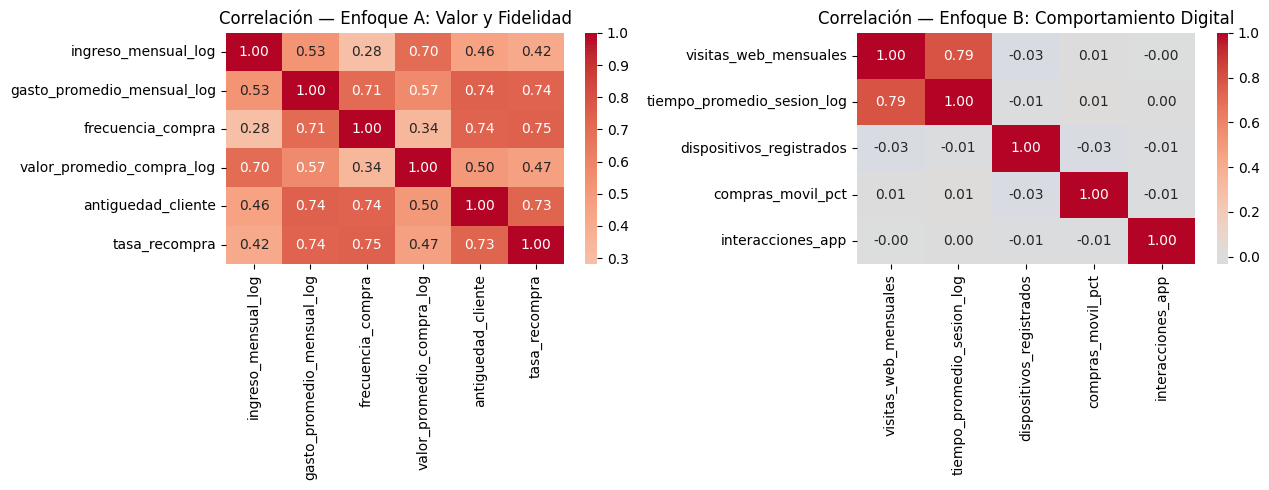

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(df[grupo_valor_fidelidad_proc].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=axes[0])
axes[0].set_title('Correlación — Enfoque A: Valor y Fidelidad')

sns.heatmap(df[grupo_comportamiento_digital_proc].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('Correlación — Enfoque B: Comportamiento Digital')

plt.tight_layout()
plt.show()


**Lectura del resultado:**

- **Enfoque A:** las correlaciones van de ~0.28 (`frecuencia_compra` vs `ingreso_mensual_log`) hasta ~0.75 (`frecuencia_compra` vs `tasa_recompra`), es decir, relaciones débiles a moderadamente altas pero coherentes con el constructo "valor y fidelidad" (más ingreso suele venir acompañado de más gasto y más recompra). **Ninguna pareja supera 0.9**, por lo que no hay redundancia crítica que justifique eliminar una variable.
- **Enfoque B:** casi todas las variables son prácticamente independientes entre sí (correlaciones cercanas a 0), con una excepción: `visitas_web_mensuales` y `tiempo_promedio_sesion_log` correlacionan en torno a **0.79**. Se decide **mantener ambas** porque, aunque relacionadas, capturan matices distintos (cuántas veces entra vs. cuánto tiempo se queda), no superan el umbral crítico (0.9) y solo son 2 de 5 variables, por lo que su peso conjunto no domina la distancia euclidiana del modelo.

**Conclusión:** no se elimina ninguna variable por correlación en ninguno de los dos enfoques.

### 2.4 Escalado (StandardScaler)

Las variables seleccionadas tienen escalas muy distintas — por ejemplo `ingreso_mensual` en miles vs. `tasa_recompra` en 0-100 vs. `dispositivos_registrados` en 1-8. K-Means usa **distancia euclidiana**, por lo que sin escalar, la variable de mayor rango numérico dominaría completamente el cálculo de distancias y el algoritmo terminaría agrupando casi exclusivamente por esa variable.

Se aplica `StandardScaler` (media 0, desviación estándar 1) **después** de seleccionar las variables y tratar el sesgo — en ese orden, porque escalar antes de decidir qué variables usar sería trabajo redundante, y escalar antes de corregir el sesgo dejaría la asimetría intacta (el escalado es una transformación lineal, no corrige forma de la distribución).

In [ ]:
scaler_A = StandardScaler()
X_A = scaler_A.fit_transform(df[grupo_valor_fidelidad_proc])

scaler_B = StandardScaler()
X_B = scaler_B.fit_transform(df[grupo_comportamiento_digital_proc])

print("Verificación post-escalado (media ≈ 0, desv. estándar ≈ 1):")
print(f"X_A -> media={X_A.mean():.3f}  std={X_A.std():.3f}")
print(f"X_B -> media={X_B.mean():.3f}  std={X_B.std():.3f}")


Verificación post-escalado (media ≈ 0, desv. estándar ≈ 1):
X_A -> media=-0.000  std=1.000
X_B -> media=0.000  std=1.000


## Parte 3 — Construcción de modelos

Se evalúa un rango de k (2 a 8) para cada enfoque, combinando dos métricas:

- **Método del codo** (inercia / WCSS): busca el punto donde agregar más clusters deja de reducir significativamente la varianza intra-cluster.
- **Coeficiente de Silhouette**: mide qué tan bien separado y compacto está cada cluster (rango -1 a 1; más alto es mejor).

In [ ]:
def evaluar_k(X, k_range=range(2, 9), random_state=42):
    inercias, siluetas = [], []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        labels = km.fit_predict(X)
        inercias.append(km.inertia_)
        siluetas.append(silhouette_score(X, labels))
    return list(k_range), inercias, siluetas

k_range, inercia_A, sil_A = evaluar_k(X_A)
_, inercia_B, sil_B = evaluar_k(X_B)

# Detección automática del codo
codo_A = KneeLocator(k_range, inercia_A, curve='convex', direction='decreasing').elbow
codo_B = KneeLocator(k_range, inercia_B, curve='convex', direction='decreasing').elbow

print(f"Codo sugerido (kneed) — Enfoque A: k = {codo_A}")
print(f"Codo sugerido (kneed) — Enfoque B: k = {codo_B}")
print(f"Mejor silhouette — Enfoque A: k = {k_range[int(np.argmax(sil_A))]} (silhouette = {max(sil_A):.3f})")
print(f"Mejor silhouette — Enfoque B: k = {k_range[int(np.argmax(sil_B))]} (silhouette = {max(sil_B):.3f})")


Codo sugerido (kneed) — Enfoque A: k = 4
Codo sugerido (kneed) — Enfoque B: k = 4
Mejor silhouette — Enfoque A: k = 2 (silhouette = 0.504)
Mejor silhouette — Enfoque B: k = 2 (silhouette = 0.256)


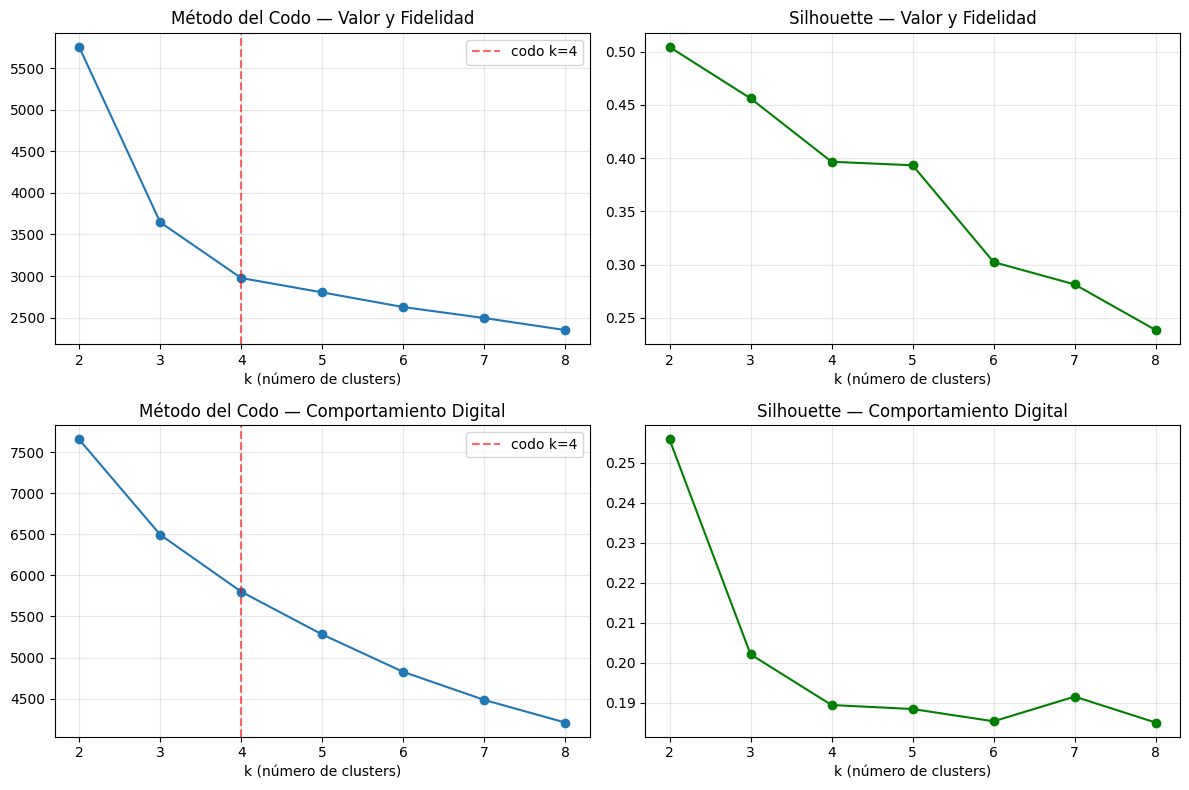

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(k_range, inercia_A, 'o-')
axes[0, 0].axvline(codo_A, color='red', ls='--', alpha=0.6, label=f'codo k={codo_A}')
axes[0, 0].set_title('Método del Codo — Valor y Fidelidad')
axes[0, 0].legend()

axes[0, 1].plot(k_range, sil_A, 'o-', color='green')
axes[0, 1].set_title('Silhouette — Valor y Fidelidad')

axes[1, 0].plot(k_range, inercia_B, 'o-')
axes[1, 0].axvline(codo_B, color='red', ls='--', alpha=0.6, label=f'codo k={codo_B}')
axes[1, 0].set_title('Método del Codo — Comportamiento Digital')
axes[1, 0].legend()

axes[1, 1].plot(k_range, sil_B, 'o-', color='green')
axes[1, 1].set_title('Silhouette — Comportamiento Digital')

for ax in axes.flat:
    ax.set_xlabel('k (número de clusters)')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Criterio para elegir el número final de clusters

Para ambos enfoques, el método del codo sugiere **k = 4**. El silhouette máximo ocurre en **k = 2** en ambos casos (esperable: con menos grupos, en promedio, es más fácil lograr separación), pero decae de forma sostenida sin un segundo quiebre claro que sugiera otro valor competitivo.

Se elige **k = 4** por sobre el silhouette máximo (k = 2) por tres razones:

1. **Granularidad de negocio:** k = 2 solo distingue "buenos vs. malos clientes", insuficiente para diseñar estrategias de marketing diferenciadas. La empresa necesita segmentos más específicos y accionables.
2. **Calidad aceptable en k = 4:** el silhouette en k = 4 sigue siendo razonable en el Enfoque A (~0.40, estructura moderadamente bien definida) y aceptable en el Enfoque B (~0.19 — más débil, pero coherente con que sus variables están casi todas incorrelacionadas entre sí: es esperable que un espacio de variables "puras" e independientes no produzca clusters tan compactos como uno con variables correlacionadas).
3. **Consistencia con el codo:** k = 4 es también donde la reducción marginal de inercia empieza a aplanarse, es decir, agregar un quinto cluster ya no reduce sustancialmente la varianza intra-cluster.

Por lo tanto, se entrena el modelo final con **k = 4 en ambos enfoques**.

In [ ]:
km_A = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster_A'] = km_A.fit_predict(X_A)

km_B = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster_B'] = km_B.fit_predict(X_B)

print("Tamaño de clusters — Enfoque A (Valor y Fidelidad):")
print(df['cluster_A'].value_counts().sort_index())
print("\nTamaño de clusters — Enfoque B (Comportamiento Digital):")
print(df['cluster_B'].value_counts().sort_index())


Tamaño de clusters — Enfoque A (Valor y Fidelidad):
cluster_A
0    533
1    500
2    497
3    470
Name: count, dtype: int64

Tamaño de clusters — Enfoque B (Comportamiento Digital):
cluster_B
0    488
1    462
2    574
3    476
Name: count, dtype: int64


### Visualización de los clusters en 2 dimensiones (PCA)

Como referencia visual adicional (no requerida por el enunciado, pero útil para comunicar calidad técnica), se proyecta cada espacio de variables a 2 componentes principales para observar la separación relativa de los clusters.

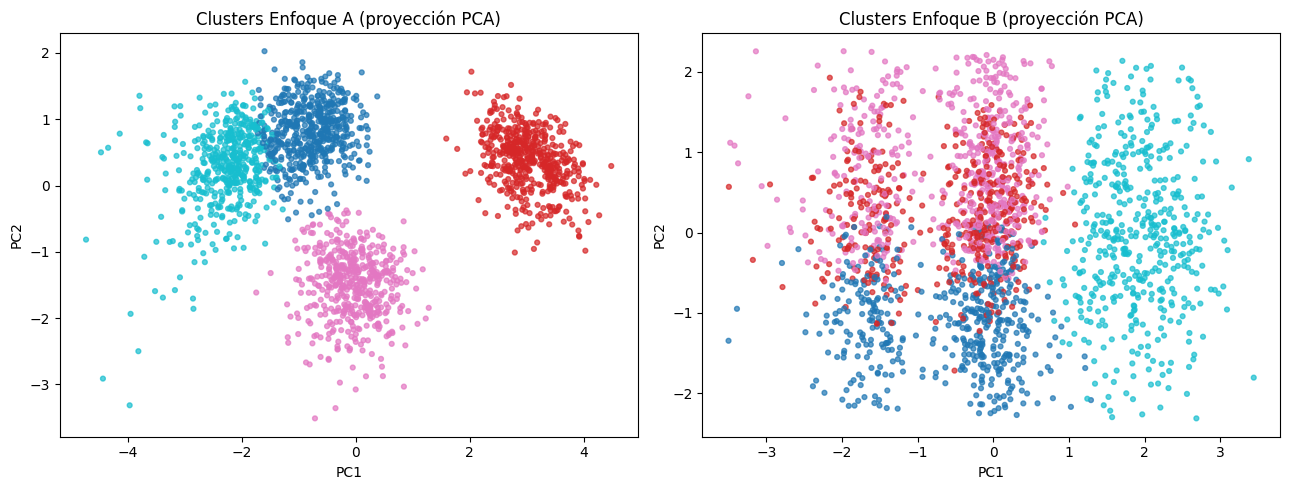

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

pca_A = PCA(n_components=2, random_state=42).fit_transform(X_A)
sc0 = axes[0].scatter(pca_A[:, 0], pca_A[:, 1], c=df['cluster_A'], cmap='tab10', s=12, alpha=0.7)
axes[0].set_title('Clusters Enfoque A (proyección PCA)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

pca_B = PCA(n_components=2, random_state=42).fit_transform(X_B)
sc1 = axes[1].scatter(pca_B[:, 0], pca_B[:, 1], c=df['cluster_B'], cmap='tab10', s=12, alpha=0.7)
axes[1].set_title('Clusters Enfoque B (proyección PCA)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()


## Parte 4 — Interpretación (análisis de negocio)

In [ ]:
perfil_A = df.groupby('cluster_A')[grupo_valor_fidelidad].mean().round(1)
perfil_A['n_clientes'] = df['cluster_A'].value_counts().sort_index()
perfil_A


,ingreso_mensual,gasto_promedio_mensual,frecuencia_compra,valor_promedio_compra,antiguedad_cliente,tasa_recompra,n_clientes
cluster_A,,,,,,,
0,4957.4,243.8,2.9,67.7,14.3,50.8,533
1,7517.9,1305.3,12.1,151.2,40.0,90.3,500
2,3002.7,355.4,10.0,35.0,25.5,70.4,497
3,3424.7,115.2,2.0,44.5,8.6,33.3,470


### Enfoque A — Valor y Fidelidad: perfiles y nombres de segmento

| Cluster | Ingreso | Gasto prom. | Frecuencia | Valor prom. compra | Antigüedad | Tasa recompra | n |
|---|---|---|---|---|---|---|---|
| 0 | 4.957 | 244 | 2.9 | 67.7 | 14.3 | 50.8% | 533 |
| 1 | 7.518 | 1.305 | 12.1 | 151.2 | 40.0 | 90.3% | 500 |
| 2 | 3.003 | 355 | 10.0 | 35.0 | 25.5 | 70.4% | 497 |
| 3 | 3.425 | 115 | 2.0 | 44.5 | 8.6 | 33.3% | 470 |

- **Cluster 1 → "Clientes VIP / Alto Valor y Fieles":** el mejor segmento en todas las dimensiones — mayor ingreso, mayor gasto, mayor frecuencia, tickets más altos, clientes antiguos (40 meses en promedio) y la mayor tasa de recompra (90%). Son la base más rentable y leal del negocio.
- **Cluster 2 → "Compradores Frecuentes de Bajo Ticket":** ingreso bajo pero compran seguido, con tickets pequeños y buena recompra (70%). Generan volumen aunque cada transacción sea pequeña.
- **Cluster 0 → "Potencial Medio sin Explotar":** ingreso medio-alto pero gasto y frecuencia bajos, recompra intermedia (51%). Tienen capacidad de gasto que hoy no se está capturando.
- **Cluster 3 → "Nuevos / Bajo Valor":** el segmento más débil — menor antigüedad (8.6 meses), gasto y frecuencia mínimos, y la peor tasa de recompra (33%). Son clientes recién llegados o en riesgo de churn temprano.

**Variable más determinante:** la combinación `gasto_promedio_mensual` + `tasa_recompra` es la que más separa a los clusters, en particular la que más distingue al Cluster 1 (VIP) del resto.

**Decisiones de negocio derivadas del Enfoque A:**
1. **Programa de fidelización premium para el Cluster 1** (beneficios exclusivos, acceso anticipado a productos) para proteger y retener a la base más rentable frente a la competencia.
2. **Campaña de reactivación temprana para el Cluster 3** (ej. descuento de bienvenida a la segunda compra, onboarding guiado) antes de que el bajo compromiso inicial se convierta en abandono definitivo.

In [ ]:
perfil_B = df.groupby('cluster_B')[grupo_comportamiento_digital].mean().round(1)
perfil_B['n_clientes'] = df['cluster_B'].value_counts().sort_index()
perfil_B


,visitas_web_mensuales,tiempo_promedio_sesion,dispositivos_registrados,compras_movil_pct,interacciones_app,n_clientes
cluster_B,,,,,,
0,30.0,11.3,4.3,37.5,21.9,488
1,29.2,10.3,1.7,40.8,27.9,462
2,30.4,10.8,3.0,82.3,24.9,574
3,92.7,30.6,2.9,56.3,24.9,476


### Enfoque B — Comportamiento Digital: perfiles y nombres de segmento

| Cluster | Visitas web | Tiempo sesión | Dispositivos | % compra móvil | Interacciones app | n |
|---|---|---|---|---|---|---|
| 0 | 30.0 | 11.3 | 4.3 | 37.5% | 21.9 | 488 |
| 1 | 29.2 | 10.3 | 1.7 | 40.8% | 27.9 | 462 |
| 2 | 30.4 | 10.8 | 3.0 | 82.3% | 24.9 | 574 |
| 3 | 92.7 | 30.6 | 2.9 | 56.3% | 24.9 | 476 |

- **Cluster 3 → "Navegantes Intensivos / Alto Engagement Web":** claramente distinto del resto — visitan el sitio ~3 veces más seguido (92.7 vs. ~30) y con sesiones ~3 veces más largas (30.6 min vs. ~11). Son quienes más "viven" en la plataforma.
- **Cluster 2 → "Mobile-First":** el 82% de sus compras se realizan desde el celular, muy por encima del resto (~40%). Compran casi exclusivamente vía app/móvil.
- **Cluster 0 → "Multi-dispositivo, Low-Mobile":** el promedio más alto de dispositivos registrados (4.3), pero solo 37.5% de compras móviles — usan varios dispositivos pero prefieren comprar desde otros canales (ej. escritorio).
- **Cluster 1 → "Digital Ligero / Single-Device":** el nivel más bajo de dispositivos registrados (1.7) y visitas/sesión moderadas — bajo compromiso tecnológico general, aunque con la interacción en app proporcionalmente más alta (27.9).

**Variable más determinante:** `compras_movil_pct` separa al Cluster 2, y el par `visitas_web_mensuales` / `tiempo_promedio_sesion` separa al Cluster 3. `dispositivos_registrados` es la que menos varía entre grupos, salvo por el Cluster 0.

**Decisiones de negocio derivadas del Enfoque B:**
1. **Optimizar la app para el Cluster 2 (Mobile-First)** — mejorar checkout móvil, notificaciones push personalizadas, ya que es el canal donde este segmento ya opera de forma natural.
2. **Investigar fricción de conversión en el Cluster 3 (Navegantes Intensivos)** — alto tráfico y tiempo en sitio no necesariamente se traduce en compra; conviene revisar el embudo (carrito abandonado, UX de checkout web) para capturar ese engagement no explotado.

In [ ]:
tabla_cruzada = pd.crosstab(df['cluster_A'], df['cluster_B'])
tabla_cruzada.index.name = 'cluster_A (Valor y Fidelidad)'
tabla_cruzada.columns.name = 'cluster_B (Comportamiento Digital)'
tabla_cruzada


cluster_B (Comportamiento Digital),0,1,2,3
cluster_A (Valor y Fidelidad),,,,
0,34,23,35,441
1,158,147,193,2
2,154,148,192,3
3,142,144,154,30


### Comparación entre ambos enfoques

La tabla cruzada muestra que los segmentos **no coinciden** entre sí, confirmando que cada enfoque captura una dimensión distinta del cliente:

- El Cluster 0 de A ("Potencial Medio sin Explotar") está fuertemente concentrado en el Cluster 3 de B ("Navegantes Intensivos"): la mayoría de esos clientes son grandes navegadores del sitio. Es decir, **navegan mucho pero compran poco** — un hallazgo que ningún modelo por sí solo hubiera mostrado, y que indica que el alto engagement digital no se está traduciendo en valor comercial.
- Los Clusters 1 y 2 de A (mayor valor/fidelidad comercial) se reparten de forma pareja entre B=0, B=1 y B=2, y casi no aparecen en B=3. Esto sugiere que los clientes más rentables **no necesariamente son los que más navegan** — probablemente ya saben lo que quieren y compran de forma directa y eficiente.
- El Cluster 3 de A (nuevos/bajo valor) se distribuye de forma pareja entre los 4 clusters de B, sin patrón digital dominante — esperable, dado que son clientes con poco historial aún.

**Qué información aporta cada segmentación:**
- El **Enfoque A** le dice al negocio *a quién* vale la pena retener, premiar o reactivar.
- El **Enfoque B** le dice *cómo* llegar a cada cliente y en qué canal invertir.

Usar ambos en conjunto (ej. cruzar "VIP y fiel" + "mobile-first" para targeting de campañas push en la app) produce una segmentación mucho más accionable que cualquiera de los dos modelos por separado.

## Parte 5 — Reflexión final

**¿Por qué dos modelos de segmentación construidos sobre conjuntos de variables diferentes pueden producir agrupaciones distintas para un mismo cliente?**

K-Means agrupa clientes minimizando la distancia euclidiana **dentro del espacio de variables que se le entrega**. Si a un mismo cliente se le mide en un espacio de "valor y fidelidad" (ingreso, gasto, frecuencia, recompra) versus un espacio de "comportamiento digital" (visitas, sesión, dispositivos, % móvil), los ejes de comparación son completamente distintos, y por lo tanto la noción de "cercanía" entre dos clientes también lo es. Un cliente puede estar muy cerca de otro en cuánto gasta, pero muy lejos en cómo navega, y viceversa — esto se observó directamente en la tabla cruzada: clientes de alto potencial comercial no explotado (Cluster 0 de A) resultaron ser, en su mayoría, los "navegantes intensivos" del Enfoque B (Cluster 3), mientras que los clientes de mayor valor (Cluster 1 de A) casi no cayeron en ese grupo digital. No hay contradicción entre ambos modelos: cada uno es correcto **dentro de su propia dimensión**, porque no existe una única forma "correcta" de agrupar a un cliente — depende de qué pregunta de negocio se quiera responder.

**Ventajas de analizar a los clientes desde múltiples perspectivas frente a un único mega-modelo:**

1. **Evita perder señales relevantes:** un solo modelo con todas las variables mezcladas tiende a diluir patrones específicos de cada dimensión — mezclar comportamiento digital con variables monetarias haría que la mayor varianza del gasto domine y opaque el patrón de navegación (o viceversa), ya que K-Means pondera implícitamente más a las variables de mayor dispersión relativa.
2. **Es más accionable para el negocio:** cada segmentación responde una pregunta de negocio distinta (a quién retener vs. por qué canal contactarlo), y cruzarlas permite diseñar campañas más precisas (ej. clientes VIP + mobile-first → notificaciones push con ofertas exclusivas en la app).
3. **Revela relaciones no obvias entre dimensiones:** como el hallazgo de que mucha navegación no implica mucha compra — un patrón que solo emerge al comparar los dos modelos entre sí, y que orienta decisiones concretas (revisar fricciones en el proceso de compra web).
4. **Reduce el riesgo de decisiones erróneas:** con un único modelo combinado se podría, por ejemplo, destinar presupuesto de marketing digital a clientes que navegan mucho pero que el otro modelo mostraría que tienen bajo valor comercial real — un mega-modelo enmascararía esa distinción al promediar ambos tipos de señal en un mismo cluster.

En síntesis, usar múltiples modelos de segmentación no es redundancia metodológica: es una forma de **preservar la resolución de cada pregunta de negocio** en lugar de comprimirlas todas en un único constructo que, en la práctica, terminaría dominado por las variables de mayor varianza.
